# Bangkok Airbnb Market Analysis
## Data Exploration & Profiling

**Author:** Sathsarani BS  
**Date:** June 2026  
**Dataset:** Inside Airbnb — Bangkok, Thailand (26 Sept 2025)

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [93]:
listings = pd.read_csv('../data/listings.csv')
print(f"Shape: {listings.shape}")
listings.head()

Shape: (28806, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27934,Nice room with superb city view,120437,Nuttee,NaN,Ratchathewi,13.75983,100.54134,Entire home/apt,1595.0,15,65,2024-09-17,0.40,1,362,0,NaN
1,27979,"Easy going landlord,easy place",120541,Emy,NaN,Bang Na,13.66818,100.61674,Private room,NaN,1,0,NaN,NaN,2,0,0,NaN
2,28745,modern-style apartment in Bangkok,123784,Familyroom,NaN,Bang Kapi,13.75232,100.62402,Private room,NaN,60,0,NaN,NaN,1,0,0,NaN
3,47516,Beautiful waterfront house,214456,Anuradha,NaN,Don Mueang,13.92726,100.58529,Entire home/apt,4188.0,3,0,NaN,NaN,1,365,0,NaN
4,48736,Condo with Chaopraya River View,222005,Athitaya,NaN,Rat Burana,13.68556,100.49535,Private room,1450.0,14,1,2014-02-03,0.01,1,365,0,NaN


In [94]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 28806 entries, 0 to 28805
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              28806 non-null  int64  
 1   name                            28806 non-null  str    
 2   host_id                         28806 non-null  int64  
 3   host_name                       28797 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   28806 non-null  str    
 6   latitude                        28806 non-null  float64
 7   longitude                       28806 non-null  float64
 8   room_type                       28806 non-null  str    
 9   price                           23273 non-null  float64
 10  minimum_nights                  28806 non-null  int64  
 11  number_of_reviews               28806 non-null  int64  
 12  last_review                     18716 non-n

In [95]:
null_summary = listings.isnull().sum()
null_pct = (null_summary / len(listings)) * 100

null_df = pd.DataFrame({
    'null_count': null_summary,
    'null_percentage': null_pct.round(2)
}).sort_values('null_percentage', ascending=False)

null_df[null_df['null_count'] > 0]

,null_count,null_percentage
license,28806,100.00
neighbourhood_group,28806,100.00
reviews_per_month,10090,35.03
last_review,10090,35.03
price,5533,19.21
host_name,9,0.03


## Data Quality Findings

- **`license`** and **`neighbourhood_group`**: 100% null — not used in Bangkok dataset, will be dropped.
- **`price`**: 19.2% missing — significant gap. These listings may be inactive or unlisted; will investigate before deciding on imputation vs. exclusion.
- **`reviews_per_month`** / **`last_review`**: 35% null — expected, as new listings without bookings naturally lack review history. Will treat as "no reviews yet" rather than missing data.

In [96]:
listings.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,2.880600e+04,2.880600e+04,0.0,28806.000000,28806.000000,23273.000000,28806.000000,28806.000000,18716.000000,28806.000000,28806.000000,28806.000000,0.0
mean,7.995041e+17,2.855787e+08,NaN,13.744811,100.562735,2528.749151,14.107373,20.250399,0.970914,25.863917,250.048462,5.839860,NaN
std,5.786117e+17,2.309697e+08,NaN,0.040952,0.049999,16473.896035,43.243299,54.799594,1.475826,41.237989,126.347399,16.500544,NaN
min,2.793400e+04,2.144700e+04,NaN,13.529370,100.328924,4.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,NaN
25%,4.021719e+07,6.287592e+07,NaN,13.720365,100.530980,923.000000,1.000000,0.000000,0.180000,2.000000,168.000000,0.000000,NaN
50%,9.946583e+17,2.258827e+08,NaN,13.739550,100.566040,1379.000000,2.000000,2.000000,0.500000,8.000000,290.000000,1.000000,NaN
75%,1.314730e+18,5.092574e+08,NaN,13.758728,100.585742,2207.000000,14.000000,17.000000,1.260000,34.000000,363.000000,5.000000,NaN
max,1.518168e+18,7.206394e+08,NaN,13.953540,100.923710,1000000.000000,1115.000000,2926.000000,57.600000,243.000000,365.000000,1304.000000,NaN


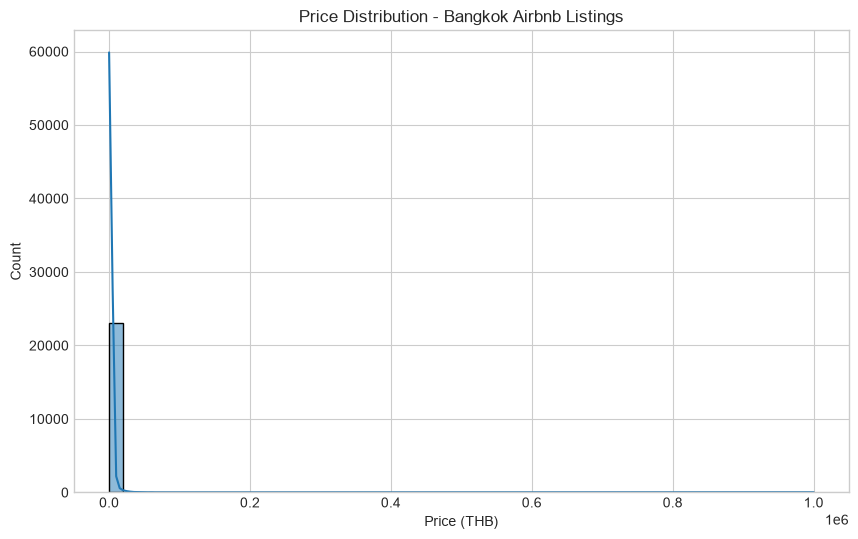

In [97]:
plt.figure(figsize=(10, 6))
sns.histplot(listings['price'].dropna(), bins=50, kde=True)
plt.title('Price Distribution - Bangkok Airbnb Listings')
plt.xlabel('Price (THB)')
plt.ylabel('Count')
plt.show()

**Observation:** The initial chart shows extreme right-skew. Let's investigate the scale of outliers before drawing conclusions.

In [98]:
print(f"Max price: {listings['price'].max()}")
print(f"99th percentile: {listings['price'].quantile(0.99)}")
print(f"95th percentile: {listings['price'].quantile(0.95)}")
print(f"Median price: {listings['price'].median()}")

Max price: 1000000.0
99th percentile: 16669.59999999992
95th percentile: 6000.0
Median price: 1379.0


**Resolution:** Capping at the 99th percentile (16,669 THB) removes extreme outliers and reveals the true market distribution.

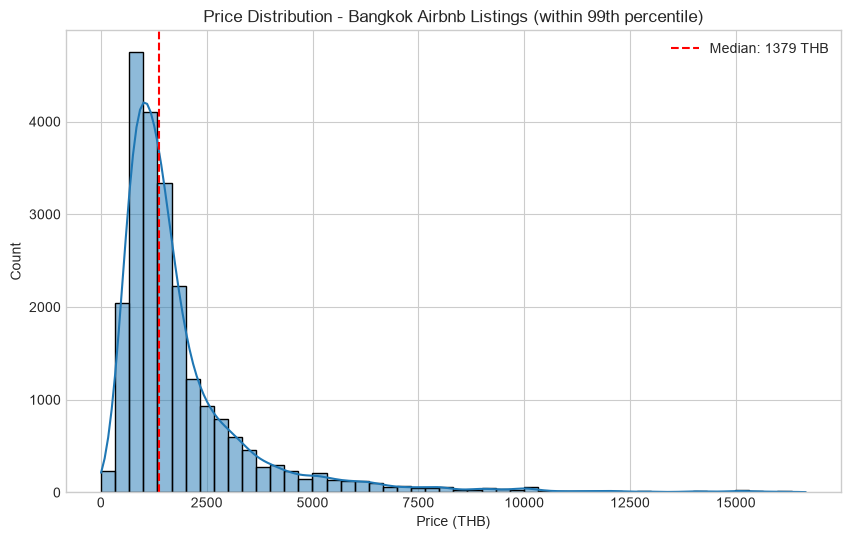

In [99]:
price_cap = listings['price'].quantile(0.99)
filtered_prices = listings[listings['price'] <= price_cap]['price'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(filtered_prices, bins=50, kde=True)
plt.title('Price Distribution - Bangkok Airbnb Listings (within 99th percentile)')
plt.xlabel('Price (THB)')
plt.ylabel('Count')
plt.axvline(listings['price'].median(), color='red', linestyle='--', label=f'Median: {listings["price"].median():.0f} THB')
plt.legend()
plt.show()

**Business Interpretation:** The cleaned distribution reveals that the majority of Bangkok 
Airbnb listings cluster between 800–2,500 THB per night, with the median at 1,379 THB. 
This represents the core budget-to-mid-range market segment that dominates supply. 
The long right tail (up to ~16,700 THB at the 99th percentile) represents a smaller 
premium/luxury segment.

**For market participants:** New hosts entering the Bangkok market should benchmark 
against the 1,000–2,000 THB range to remain competitive within the dominant supply 
cluster, unless specifically targeting the luxury segment where differentiation 
(unique amenities, prime location) becomes critical to justify premium pricing.

### Price by Room Type

Now let's examine how room type — Entire home/apt, Private room, Shared room — 
influences pricing. This will inform our first hypothesis test (H1: entire-home 
listings command significantly higher prices than private rooms).

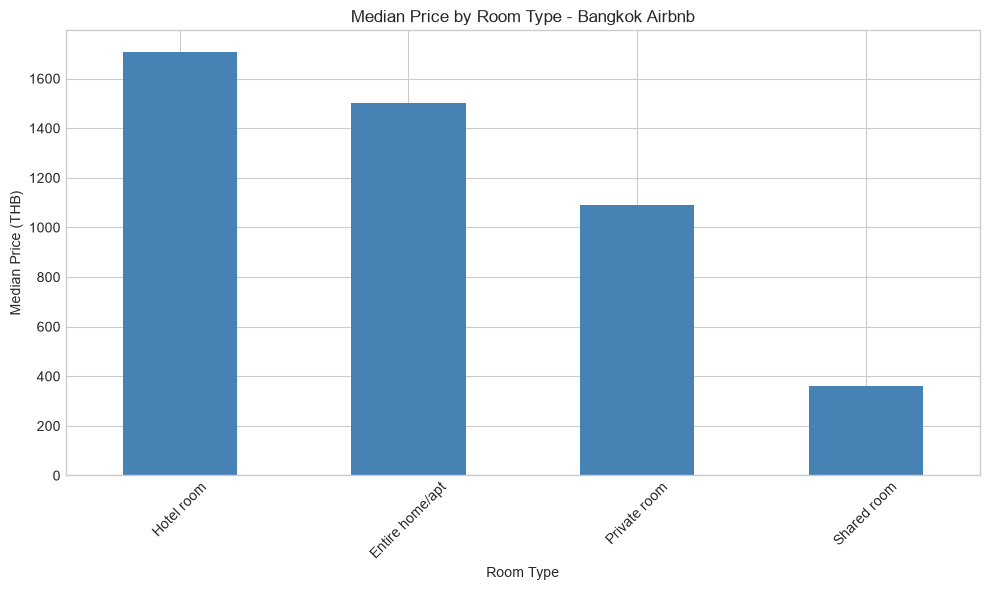

In [100]:
plt.figure(figsize=(10, 6))
room_type_price = listings.groupby('room_type')['price'].median().sort_values(ascending=False)
room_type_price.plot(kind='bar', color='steelblue')
plt.title('Median Price by Room Type - Bangkok Airbnb')
plt.xlabel('Room Type')
plt.ylabel('Median Price (THB)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business Interpretation:** Contrary to typical assumptions, "Hotel room" listings 
command the highest median price (~1,700 THB), slightly exceeding "Entire home/apt" 
(~1,500 THB). This likely reflects professionally-managed hotel inventory listed via 
Airbnb, which carries hospitality-grade amenities and service standards justifying 
premium pricing. "Private room" (~1,050 THB) and "Shared room" (~400 THB) show the 
expected step-down in price as guests trade privacy for affordability.

**For hosts:** Entire-home hosts compete in a tighter price band against professional 
hotel operators, suggesting differentiation through unique local experiences or 
amenities may be necessary to justify premium pricing against hotel-grade alternatives.

**For H1 hypothesis testing:** This visual comparison sets up our formal statistical 
test — we'll verify whether the Entire home/apt vs. Private room price gap is 
statistically significant in Section 5.

## 5. Statistical Analysis

### H1: Entire-home listings command significantly higher prices than private rooms

**Null Hypothesis (H0):** No significant difference in price between Entire home/apt 
and Private room listings.  
**Alternative Hypothesis (H1):** Entire home/apt listings have significantly higher 
prices than Private room listings.

In [101]:
from scipy import stats

entire_home = listings[listings['room_type'] == 'Entire home/apt']['price'].dropna()
private_room = listings[listings['room_type'] == 'Private room']['price'].dropna()

print(f"Entire home/apt — n={len(entire_home)}, median={entire_home.median():.0f} THB")
print(f"Private room — n={len(private_room)}, median={private_room.median():.0f} THB")

# Mann-Whitney U test (non-parametric, since price is right-skewed — not normally distributed)
u_stat, p_value = stats.mannwhitneyu(entire_home, private_room, alternative='greater')

print(f"\nMann-Whitney U statistic: {u_stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

Entire home/apt — n=16498, median=1500 THB
Private room — n=6263, median=1090 THB

Mann-Whitney U statistic: 66431200
P-value: 0.000000
Significant at α=0.05: Yes


### Statistical vs. Practical Significance

The p-value (0.000000) confirms the difference is **statistically significant** — 
but with a large sample size (n=22,761 combined), even small differences can produce 
extremely low p-values. This doesn't tell us whether the *magnitude* of the difference 
matters in practice.

To assess **practical significance**, we calculate Cohen's d, which measures the 
standardized size of the difference between the two groups, independent of sample size.

In [102]:
# Effect size (Cohen's d) - measures practical significance
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(entire_home, private_room)
print(f"Cohen's d: {d:.3f}")

if abs(d) < 0.2:
    interpretation = "negligible"
elif abs(d) < 0.5:
    interpretation = "small"
elif abs(d) < 0.8:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"Effect size interpretation: {interpretation}")

Cohen's d: 0.046
Effect size interpretation: negligible


**Statistical Conclusion:** With p < 0.001, we reject the null hypothesis. Entire-home 
listings command significantly higher prices than private rooms — a 410 THB median 
gap (1,500 vs 1,090 THB), representing a ~38% premium. However, the Cohen's d of 0.046 
indicates this is a **negligible** practical effect size, meaning the distributions of 
the two groups overlap substantially despite the statistically significant median 
difference.

**Why the discrepancy?** With a large combined sample (n=22,761), even small 
differences become statistically detectable. The p-value tells us the difference is 
*real* (unlikely due to chance), but Cohen's d tells us the difference is *small* 
relative to the natural price variation within each group. Both findings are valid — 
they answer different questions.

**Methodology note:** Mann-Whitney U test was selected over an independent t-test 
because price data is heavily right-skewed (confirmed in Section 4.1), violating 
the normality assumption required for parametric tests.

**For market participants:** While entire-home listings do command a premium on 
average, the negligible effect size suggests price alone is not the dominant factor 
differentiating these two segments — other variables (location, amenities, host 
reputation) likely explain more of the price variation than room type does.